В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

Numeric columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical columns: ['Geography', 'Gender']
Area under ROC score on Train dataset: 88.25%
Accuracy on Train dataset: 87.45%
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      9558
         1.0       0.77      0.55      0.64      2442

    accuracy                           0.87     12000
   macro avg       0.83      0.75      0.78     12000
weighted avg       0.87      0.87      0.87     12000



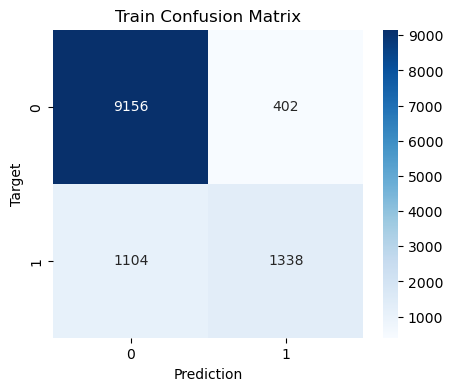

Area under ROC score on Validation dataset: 87.97%
Accuracy on Validation dataset: 86.97%
              precision    recall  f1-score   support

         0.0       0.90      0.95      0.92      2390
         1.0       0.73      0.57      0.64       610

    accuracy                           0.87      3000
   macro avg       0.81      0.76      0.78      3000
weighted avg       0.86      0.87      0.86      3000



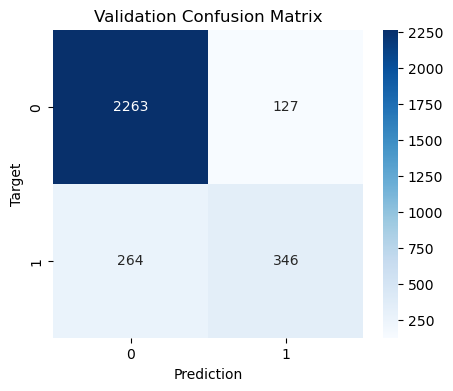

['artifacts/log_reg_pipeline.joblib']

In [1]:
import os
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

DATA_DIR = "data"
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

raw_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"), index_col=0)

train_df, val_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=42,
    stratify=raw_df["Exited"]
)

# Створюємо трен. і вал. набори
target_col = "Exited"

# CustomerId та Surname не використовуємо як корисні ознаки для моделі:
# CustomerId — технічний ідентифікатор, Surname має багато унікальних значень.
drop_cols = [target_col, "CustomerId", "Surname"]
input_cols = [col for col in raw_df.columns if col not in drop_cols]

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include="object").columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Створюємо пайплайн, який спочатку запускає препроцесинг, потім тренує модель
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=""):
    preds = model_pipeline.predict(inputs)
    pred_proba = model_pipeline.predict_proba(inputs)[:, 1]

    roc_auc = roc_auc_score(targets, pred_proba) * 100
    accuracy = accuracy_score(targets, preds) * 100

    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    print(f"Accuracy on {name} dataset: {accuracy:.2f}%")
    print(classification_report(targets, preds))

    confusion_matrix_ = confusion_matrix(targets, preds)

    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix_, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Prediction")
    plt.ylabel("Target")
    plt.title("{} Confusion Matrix".format(name))
    plt.show()

    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, "Train")
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, "Validation")

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, os.path.join(ARTIFACTS_DIR, "log_reg_pipeline.joblib"))

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train Polynomial degree 2 dataset: 93.10%
Accuracy on Train Polynomial degree 2 dataset: 90.15%
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      9558
         1.0       0.81      0.68      0.74      2442

    accuracy                           0.90     12000
   macro avg       0.86      0.82      0.84     12000
weighted avg       0.90      0.90      0.90     12000



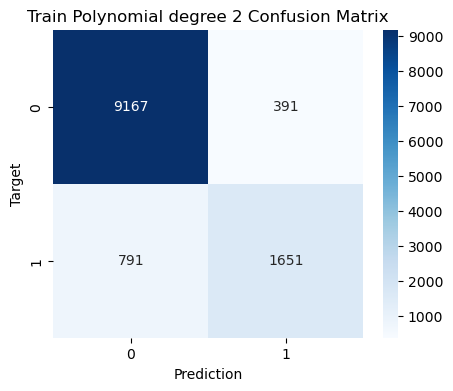

Area under ROC score on Validation Polynomial degree 2 dataset: 92.84%
Accuracy on Validation Polynomial degree 2 dataset: 89.50%
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94      2390
         1.0       0.78      0.68      0.72       610

    accuracy                           0.90      3000
   macro avg       0.85      0.81      0.83      3000
weighted avg       0.89      0.90      0.89      3000



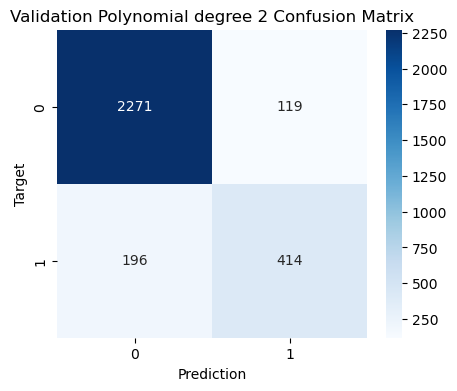

,id,Exited
0,15000,0.091235
1,15001,0.014654
2,15002,0.071588
3,15003,0.373664
4,15004,0.024321


In [8]:
from sklearn.preprocessing import PolynomialFeatures

# Новий трансформер для числових колонок: масштабування + polynomial features degree=2
numeric_transformer_poly_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

categorical_transformer_poly_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_poly_2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_poly_2, numeric_cols),
        ("cat", categorical_transformer_poly_2, categorical_cols)
    ]
)

model_pipeline_poly_2 = Pipeline(steps=[
    ("preprocessor", preprocessor_poly_2),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

model_pipeline_poly_2.fit(train_inputs, train_targets)

train_preds_poly_2 = predict_and_plot(
    model_pipeline_poly_2,
    train_inputs,
    train_targets,
    "Train Polynomial degree 2"
)

val_preds_poly_2 = predict_and_plot(
    model_pipeline_poly_2,
    val_inputs,
    val_targets,
    "Validation Polynomial degree 2"
)

joblib.dump(
    model_pipeline_poly_2,
    os.path.join(ARTIFACTS_DIR, "log_reg_pipeline_poly_2.joblib")
)

test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"), index_col=0)
sample_submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

test_inputs = test_df[input_cols].copy()

#  Kaggle
best_model = model_pipeline_poly_2

test_predictions_proba = best_model.predict_proba(test_inputs)[:, 1]

submission = sample_submission.copy()
submission["Exited"] = test_predictions_proba

submission_path = os.path.join(ARTIFACTS_DIR, "submission_poly_2.csv")
submission.to_csv(submission_path, index=False)

submission.head()

**Висновок для моделі з polynomial features degree=2:**

Виведені вище значення ROC-AUC train і validation близькі та достатньо високі (~93%) — модель достатньо добре генералізує.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train Polynomial degree 4 dataset: 94.56%
Accuracy on Train Polynomial degree 4 dataset: 90.80%
              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94      9558
         1.0       0.83      0.69      0.75      2442

    accuracy                           0.91     12000
   macro avg       0.88      0.83      0.85     12000
weighted avg       0.90      0.91      0.90     12000



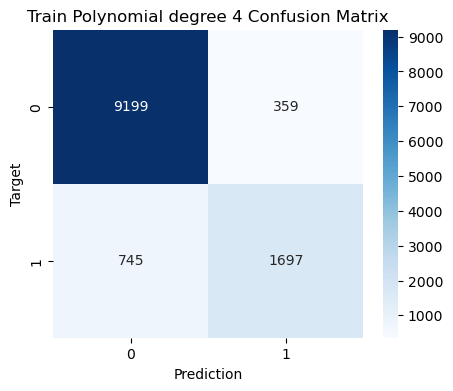

Area under ROC score on Validation Polynomial degree 4 dataset: 92.42%
Accuracy on Validation Polynomial degree 4 dataset: 89.07%
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93      2390
         1.0       0.77      0.67      0.71       610

    accuracy                           0.89      3000
   macro avg       0.84      0.81      0.82      3000
weighted avg       0.89      0.89      0.89      3000



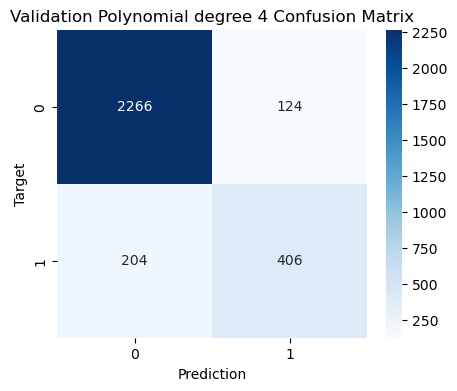

['artifacts/log_reg_pipeline_poly_4.joblib']

In [3]:
# Новий трансформер для числових колонок: масштабування + polynomial features degree=4
numeric_transformer_poly_4 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=4, include_bias=False))
])

categorical_transformer_poly_4 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_poly_4 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_poly_4, numeric_cols),
        ("cat", categorical_transformer_poly_4, categorical_cols)
    ]
)

model_pipeline_poly_4 = Pipeline(steps=[
    ("preprocessor", preprocessor_poly_4),
    ("classifier", LogisticRegression(max_iter=3000, random_state=42))
])

model_pipeline_poly_4.fit(train_inputs, train_targets)

train_preds_poly_4 = predict_and_plot(
    model_pipeline_poly_4,
    train_inputs,
    train_targets,
    "Train Polynomial degree 4"
)

val_preds_poly_4 = predict_and_plot(
    model_pipeline_poly_4,
    val_inputs,
    val_targets,
    "Validation Polynomial degree 4"
)

joblib.dump(
    model_pipeline_poly_4,
    os.path.join(ARTIFACTS_DIR, "log_reg_pipeline_poly_4.joblib")
)

**Висновок для моделі з polynomial features degree=4:**

Якість моделі трохи погіршилась: значення ROC AUC впало з 93 до 92%. При цьому вирісла різниця між train та validation даними (94/92), значить модель трохи гірше генералізує порівняно з попередньою.


**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

regression_df = pd.read_csv(os.path.join(DATA_DIR, "regression_data.csv"))

regression_df.head()

regression_target_col = "target"
regression_input_cols = [col for col in regression_df.columns if col != regression_target_col]

regression_inputs = regression_df[regression_input_cols].copy()
regression_targets = regression_df[regression_target_col].copy()

reg_train_inputs, reg_test_inputs, reg_train_targets, reg_test_targets = train_test_split(
    regression_inputs,
    regression_targets,
    test_size=0.2,
    random_state=42
)

linear_poly_5_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("model", LinearRegression())
])

linear_poly_5_pipeline.fit(reg_train_inputs, reg_train_targets)

def evaluate_regression_model(model, inputs, targets, name=""):
    preds = model.predict(inputs)

    mae = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    r2 = r2_score(targets, preds)

    print(f"{name} MAE: {mae:.4f}")
    print(f"{name} RMSE: {rmse:.4f}")
    print(f"{name} R2: {r2:.4f}")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

linear_poly_5_train_metrics = evaluate_regression_model(
    linear_poly_5_pipeline,
    reg_train_inputs,
    reg_train_targets,
    "Linear Regression Polynomial degree 5 Train"
)

linear_poly_5_test_metrics = evaluate_regression_model(
    linear_poly_5_pipeline,
    reg_test_inputs,
    reg_test_targets,
    "Linear Regression Polynomial degree 5 Test"
)

Linear Regression Polynomial degree 5 Train MAE: 0.0000
Linear Regression Polynomial degree 5 Train RMSE: 0.0000
Linear Regression Polynomial degree 5 Train R2: 1.0000
Linear Regression Polynomial degree 5 Test MAE: 23.0011
Linear Regression Polynomial degree 5 Test RMSE: 35.6281
Linear Regression Polynomial degree 5 Test R2: 0.4559


**Висновок:**

Ця модель є явним прикладом перенавчання. На train даних вона досягла ідеальної якості (MAE = 0, RMSE = 0, R² = 1), що свідчить про практично повне запам'ятовування навчальної вибірки. Однак на тестових даних якість значно погіршується (R² ≈ 0.46), тому модель погано узагальнює нові дані. Ймовірною причиною є надто високий ступінь полінома (degree = 5), через що модель стала занадто складною.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [7]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

regularized_models = {
    "Lasso": Lasso(alpha=0.1, max_iter=20000, random_state=42),
    "Ridge": Ridge(alpha=10.0, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000, random_state=42)
}

regularized_results = []

for model_name, model in regularized_models.items():
    pipeline = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=20, include_bias=False)),
        ("model", model)
    ])

    pipeline.fit(reg_train_inputs, reg_train_targets)

    train_preds = pipeline.predict(reg_train_inputs)
    test_preds = pipeline.predict(reg_test_inputs)

    train_mae = mean_absolute_error(reg_train_targets, train_preds)
    train_rmse = np.sqrt(mean_squared_error(reg_train_targets, train_preds))
    train_r2 = r2_score(reg_train_targets, train_preds)

    test_mae = mean_absolute_error(reg_test_targets, test_preds)
    test_rmse = np.sqrt(mean_squared_error(reg_test_targets, test_preds))
    test_r2 = r2_score(reg_test_targets, test_preds)

    regularized_results.append({
        "model": model_name,
        "train_MAE": train_mae,
        "train_RMSE": train_rmse,
        "train_R2": train_r2,
        "test_MAE": test_mae,
        "test_RMSE": test_rmse,
        "test_R2": test_r2,
        "R2_gap": train_r2 - test_r2,
        "non_null_coef": np.sum(model.coef_ != 0)
    })

regularized_results_df = pd.DataFrame(regularized_results)
# Додамо для порівняння LinearRegression з degree=5 з попереднього завдання
comparison_df = pd.DataFrame([
    {
        "model": "LinearRegression degree 5",
        "train_MAE": linear_poly_5_train_metrics["MAE"],
        "train_RMSE": linear_poly_5_train_metrics["RMSE"],
        "train_R2": linear_poly_5_train_metrics["R2"],
        "test_MAE": linear_poly_5_test_metrics["MAE"],
        "test_RMSE": linear_poly_5_test_metrics["RMSE"],
        "test_R2": linear_poly_5_test_metrics["R2"],
        "R2_gap": linear_poly_5_train_metrics["R2"] - linear_poly_5_test_metrics["R2"],
    }
])

all_results_df = pd.concat([comparison_df, regularized_results_df], ignore_index=True)
all_results_df.sort_values(by="test_R2", ascending=False)
best_model_row = all_results_df.sort_values(
    by=["test_R2", "R2_gap"],
    ascending=[False, True]
).iloc[0]

print(f"Найкраща модель за test R2: {best_model_row['model']}")
print(best_model_row)
# Додатковий аналіз: кількість поліноміальних ознак degree=20
poly_20 = PolynomialFeatures(degree=20, include_bias=False)
poly_20.fit(reg_train_inputs)

print(f"Початкова кількість ознак: {reg_train_inputs.shape[1]}")
print(f"Кількість ознак після PolynomialFeatures degree=20: {poly_20.n_output_features_}")
print(f"Кількість значущих ознак: {best_model_row["non_null_coef"]}")

Найкраща модель за test R2: Lasso
model                Lasso
train_MAE         0.362208
train_RMSE        0.657481
train_R2          0.999778
test_MAE          7.706342
test_RMSE        17.377412
test_R2           0.870568
R2_gap            0.129211
non_null_coef       5961.0
Name: 1, dtype: object
Початкова кількість ознак: 5
Кількість ознак після PolynomialFeatures degree=20: 53129
Кількість значущих ознак: 5961.0


**Висновок:**

Цей результат показує, як регуляризація Lasso може врятувати модель від перенавчання навіть коли кількість ознак стала величезною. За рахунок поліному 20-го ступеню кількість ознак збільшилась з 5 до 53129. Звичайна модель лінійної регресії використала тисячі непотрібних ознак і запам'ятала навчальні дані. Але за допомогою регулярізації Лассо в результаті були використані лише 5961 ознака і показник R² збільшився з 0.46 до 0.87, що є дуже добрим результатом.